# 5.0 — Data Preparation (v2)

## Changes from v1 (based on professor feedback)
- Reduced to 3 core clinical variables: UPDRS-III (OFF), MoCA, Hoehn & Yahr
- UPDRS-III filtered to OFF state only (PDSTATE == 3.0 or NaN)
- SC(Screening)↔BL(Baseline) EVENT_ID cross-mapping recovers ~119 additional patients
- Manual summation retained (NP3TOT not present in this PPMI download)
- UPDRS-IV, RBD, disease duration dropped

## 1. Imports and Configuration

In [1]:

import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# File paths 
# LATENT_FILE_TRAIN    = '../../data/baseline/train_mu_beta_3.00e-05.csv'
# LATENT_FILE_VAL      = '../../data/baseline/val_mu_beta_3.00e-05.csv'

LATENT_FILE_TRAIN    = '../../data/baseline/final_train_combined_vae_data.csv'
LATENT_FILE_VAL      = '../../data/baseline/final_validation_combined_vae_data.csv'

CLINICAL_DIR   = '../../data/raw/ppmi_clinical/'
UPDRS_III_FILE = os.path.join(CLINICAL_DIR, 'MDS-UPDRS_Part_III_06Jul2026.csv')
MOCA_FILE      = os.path.join(CLINICAL_DIR, 'Montreal_Cognitive_Assessment__MoCA__08Jul2026.csv')

TRAIN_OUT      = '../../data/processed/clinical_merged/train_v2.csv'
VAL_OUT        = '../../data/processed/clinical_merged/val_v2.csv'
SCALER_OUT     = '../../results/models/scaler_sbr_v2.pkl'
PCA_OUT        = '../../results/models/pca_sbr_v2.pkl'

os.makedirs('../../data/processed/clinical_merged', exist_ok=True)
os.makedirs('../../results/models', exist_ok=True)

# ── Parameters ─────────────────────────────────────────────────────────────────
TRAIN_RATIO    = 0.8
RANDOM_STATE   = 42
JOIN_KEY       = ['PATNO', 'EVENT_ID']
PATIENT_COL    = 'PATNO'
LABEL_COL      = 'label'
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]
N_SBR_PCS = 3

print("Configuration loaded.")

Configuration loaded.


## 2. Load Latent Vectors

In [3]:
df_latents = pd.read_csv(LATENT_FILE_TRAIN)
df_latents_val = pd.read_csv(LATENT_FILE_VAL)

print("Latent vectors")
print(f"Shape:           {df_latents.shape}")
print(f"Unique patients: {df_latents[PATIENT_COL].nunique()}")
print(f"Total rows:      {len(df_latents)}")
print(f"\nLabel counts:")
print(df_latents[LABEL_COL].value_counts().to_string())
print(f"Columns {df_latents.columns.tolist()}")

if 'EVENT_ID' in df_latents.columns:
    print(f"\nEVENT_ID distribution (top 10):")
    print(df_latents['EVENT_ID'].value_counts().head(10).to_string())
else:
    print("EVENT_ID column not found in the dataframe.")    


Latent vectors
Shape:           (2373, 303)
Unique patients: 1437
Total rows:      2373

Label counts:
label
PD         2030
Control     233
SWEDD       110
Columns ['FilePath', 'PATNO', 'label', 'latent_0', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'latent_5', 'latent_6', 'latent_7', 'latent_8', 'latent_9', 'latent_10', 'latent_11', 'latent_12', 'latent_13', 'latent_14', 'latent_15', 'latent_16', 'latent_17', 'latent_18', 'latent_19', 'latent_20', 'latent_21', 'latent_22', 'latent_23', 'latent_24', 'latent_25', 'latent_26', 'latent_27', 'latent_28', 'latent_29', 'latent_30', 'latent_31', 'latent_32', 'latent_33', 'latent_34', 'latent_35', 'latent_36', 'latent_37', 'latent_38', 'latent_39', 'latent_40', 'latent_41', 'latent_42', 'latent_43', 'latent_44', 'latent_45', 'latent_46', 'latent_47', 'latent_48', 'latent_49', 'latent_50', 'latent_51', 'latent_52', 'latent_53', 'latent_54', 'latent_55', 'latent_56', 'latent_57', 'latent_58', 'latent_59', 'latent_60', 'latent_61', 'latent_

## 3. Load and Preprocess UPDRS-III
#### OFF state only

In [4]:
df_updrs3_raw = pd.read_csv(UPDRS_III_FILE)

print("UPDRS-III raw ")
print(f"Shape: {df_updrs3_raw.shape}")
print(f"\nPDSTATE distribution:")
print(df_updrs3_raw['PDSTATE'].value_counts(dropna=False).to_string())
print(f"\nEVENT_ID distribution (top 10):")
print(df_updrs3_raw['EVENT_ID'].value_counts().head(10).to_string())

# Filter to OFF state only
df_updrs3 = df_updrs3_raw[
    (df_updrs3_raw['PDSTATE'] == 'OFF') | (df_updrs3_raw['PDSTATE'].isna())
].copy()

print(f"\nAfter OFF state filter ")
print(f"Rows before: {len(df_updrs3_raw)}")
print(f"Rows after:  {len(df_updrs3)}")
print(f"  Explicit OFF (PDSTATE='OFF'): {(df_updrs3['PDSTATE']=='OFF').sum()}")
print(f"  Assumed OFF (PDSTATE=NaN):  {df_updrs3['PDSTATE'].isna().sum()}")


# Use precomputed NP3TOT
df_updrs3 = df_updrs3[JOIN_KEY + ['NP3TOT', 'NHY']].dropna(subset=['NP3TOT'])
df_updrs3 = df_updrs3.rename(columns={'NP3TOT': 'UPDRS3_TOTAL', 'NHY': 'HOEHN_YAHR'})# Rename columns for clarity

print(f"\nUPDRS-III final ")
print(f"Rows:            {len(df_updrs3)}")
print(f"Columns:            {df_updrs3.columns.tolist()}")
print(f"Unique patients: {df_updrs3['PATNO'].nunique()}")
print(f"Score range:     {df_updrs3['UPDRS3_TOTAL'].min():.0f} – {df_updrs3['UPDRS3_TOTAL'].max():.0f}")
print(f"Mean ± std:      {df_updrs3['UPDRS3_TOTAL'].mean():.1f} ± {df_updrs3['UPDRS3_TOTAL'].std():.1f}")
print(df_updrs3.head())

UPDRS-III raw 
Shape: (38626, 65)

PDSTATE distribution:
PDSTATE
NaN    21372
ON      9802
OFF     7452

EVENT_ID distribution (top 10):
EVENT_ID
BL     5382
V04    4356
V06    3771
V08    2598
V05    2239
V02    2147
V10    1832
V12    1416
SC     1171
V14    1099

After OFF state filter 
Rows before: 38626
Rows after:  28824
  Explicit OFF (PDSTATE='OFF'): 7452
  Assumed OFF (PDSTATE=NaN):  21372

UPDRS-III final 
Rows:            23405
Columns:            ['PATNO', 'EVENT_ID', 'UPDRS3_TOTAL', 'HOEHN_YAHR']
Unique patients: 5151
Score range:     0 – 100
Mean ± std:      14.2 ± 14.7
   PATNO EVENT_ID  UPDRS3_TOTAL  HOEHN_YAHR
0   3000       BL           4.0         0.0
1   3000      V04           1.0         0.0
2   3000      V06           4.0         0.0
3   3000      V08           2.0         0.0
4   3000      V10          19.0         0.0


## 4. Load MoCA

In [5]:
df_moca_raw = pd.read_csv(MOCA_FILE)

# MCATOT is the precomputed total score (0-30)
df_moca = df_moca_raw[JOIN_KEY + ['MCATOT']].dropna(subset=['MCATOT'])
df_moca = df_moca.rename(columns={'MCATOT': 'MOCA_TOTAL'})

print("MoCA")
print(f"Rows:            {len(df_moca)}")
print(f"Unique patients: {df_moca[PATIENT_COL].nunique()}")
print(f"Score range:     {df_moca['MOCA_TOTAL'].min():.0f} – {df_moca['MOCA_TOTAL'].max():.0f}")
print(f"Mean ± std:      {df_moca['MOCA_TOTAL'].mean():.1f} ± {df_moca['MOCA_TOTAL'].std():.1f}")
print(f"\nEVENT_ID distribution (top 5):")
print(df_moca_raw['EVENT_ID'].value_counts().head(5).to_string())

print(f"\nPATNO range:")
print(f"  min: {df_moca['PATNO'].min()}")
print(f"  max: {df_moca['PATNO'].max()}")
print("\nColumns: ", df_moca.columns.tolist())

MoCA
Rows:            19974
Unique patients: 5478
Score range:     0 – 30
Mean ± std:      26.8 ± 2.9

EVENT_ID distribution (top 5):
EVENT_ID
V04    3653
BL     2972
V06    2902
SC     2565
V08    1862

PATNO range:
  min: 3000
  max: 660264

Columns:  ['PATNO', 'EVENT_ID', 'MOCA_TOTAL']


In [6]:
# Moca Coverage in latent vectors
moca_max = df_moca['PATNO'].max()
missing  = df_latents[~df_latents['PATNO'].isin(df_moca['PATNO'])].drop_duplicates('PATNO')


# print(missing['PATNO'].head(5))
# print(missing['PATNO'] > moca_max)
print(f"MoCA table max PATNO: {moca_max}")
print(f"\nMissing patients total: {len(missing)}")

print(f"\n  PATNO > {moca_max} (newer cohort): {(missing['PATNO'] > moca_max).sum()}") 
print(f"  PATNO <= {moca_max} (should be covered): {(missing['PATNO'] <= moca_max).sum()}")
print(f"  Max of PATNO in latent vectors: {df_latents['PATNO'].max()}")

print(f"\nLatent vectors coverage:")
print(f"  Total latent vectors: {len(df_latents)}")
print(f"  Unique patients:      {df_latents[PATIENT_COL].nunique()}")
print(f"  Unique patients with MoCA: {df_latents[df_latents[PATIENT_COL].isin(df_moca[PATIENT_COL])][PATIENT_COL].nunique()}")  

MoCA table max PATNO: 660264

Missing patients total: 19

  PATNO > 660264 (newer cohort): 0
  PATNO <= 660264 (should be covered): 19
  Max of PATNO in latent vectors: 239077

Latent vectors coverage:
  Total latent vectors: 2373
  Unique patients:      1437
  Unique patients with MoCA: 1418


In [7]:
# Split into old and new cohort
moca_max = df_moca['PATNO'].max()  # 92,834

old_cohort = df_latents[df_latents['PATNO'] <= moca_max].drop_duplicates('PATNO')
new_cohort = df_latents[df_latents['PATNO'] >  moca_max].drop_duplicates('PATNO')

moca_patnos = set(df_moca['PATNO'].unique())

old_covered = old_cohort[old_cohort['PATNO'].isin(moca_patnos)]
old_missing = old_cohort[~old_cohort['PATNO'].isin(moca_patnos)]

print(f"Old cohort (PATNO <= {moca_max}):")
print(f"  Total patients:    {len(old_cohort)}")
print(f"  With MoCA:         {len(old_covered)}")
print(f"  Without MoCA:      {len(old_missing)}")
print(f"  Coverage:          {len(old_covered)/len(old_cohort)*100:.1f}%")

print(f"\nNew cohort (PATNO > {moca_max}):")
print(f"  Total patients:    {len(new_cohort)}")
print(f"  Coverage:          0% (not in MoCA download)")

Old cohort (PATNO <= 660264):
  Total patients:    1437
  With MoCA:         1418
  Without MoCA:      19
  Coverage:          98.7%

New cohort (PATNO > 660264):
  Total patients:    0
  Coverage:          0% (not in MoCA download)


## 5. Merge Clinical Data with Latent Vectors
**SC(Screening)↔BL(Baseline) cross-mapping fix:**  
At enrollment, DaTSCAN is often acquired at EVENT_ID = SC while UPDRS/MoCA  
are measured at EVENT_ID = BL (or vice versa). A two-step merge recovers  
these patients: first exact match, then SC↔BL remapped match for unmatched rows.


### Fix Event ID Matching

In [8]:
# MERGE-WITH-SCBL-FIX

def merge_with_scbl_fix(df_base, df_clinical, clinical_cols, label):
    """
    Two-step merge:
    1. Exact match on PATNO + EVENT_ID
    2. SC<->BL remap for unmatched rows
    """
    # Reset index to avoid multi-index issues
    df_base = df_base.reset_index(drop=True)
    df_clinical = df_clinical.reset_index(drop=True)

    # Step 1 — exact match
    merged = df_base.merge(
        df_clinical[JOIN_KEY + clinical_cols],
        on=JOIN_KEY,
        how='left'
    )

    # Step 2 — SC-BL remap for rows still missing clinical data
    missing_mask = merged[clinical_cols[0]].isna()
    n_missing_before = missing_mask.sum()

    if missing_mask.sum() > 0:
        sc_bl_map = {'SC': 'BL', 'BL': 'SC'}
        df_clinical_remapped = df_clinical.copy()
        df_clinical_remapped['EVENT_ID'] = df_clinical_remapped['EVENT_ID'].replace(sc_bl_map)

        # Merge only the missing rows with remapped clinical table
        missing_rows = df_base[missing_mask].copy()
        fallback = missing_rows.merge(
            df_clinical_remapped[JOIN_KEY + clinical_cols],
            on=JOIN_KEY,
            how='left'
        )

        # Fill missing values from fallback
        for col in clinical_cols:
            merged.loc[missing_mask, col] = fallback[col].values

    n_missing_after = merged[clinical_cols[0]].isna().sum()
    n_recovered = n_missing_before - n_missing_after

    print(f"  {label}:")
    print(f"    Matched (exact):    {(~merged[clinical_cols[0]].isna()).sum()- n_recovered}")
    print(f"    Recovered (SC-BL): {n_recovered}")
    print(f"    Total matched:      {(~merged[clinical_cols[0]].isna()).sum()} / {len(df_base)} rows ({(~merged[clinical_cols[0]].isna()).sum()/len(df_base)*100:.1f}%)")
    print()
    # print(merged.head())
    return merged

print("=== Merging clinical tables ===\n")

df = df_latents.copy().reset_index(drop=True)
print(f"Initial shape: {df.shape}")

# Merge UPDRS-III and Hoehn & Yahr
df = merge_with_scbl_fix(df, df_updrs3, ['UPDRS3_TOTAL', 'HOEHN_YAHR'], 'UPDRS-III + H&Y')

# Merge MoCA
df = merge_with_scbl_fix(df, df_moca, ['MOCA_TOTAL'], 'MoCA')

print(f"Final shape: {df.shape}")

=== Merging clinical tables ===

Initial shape: (2373, 303)
  UPDRS-III + H&Y:
    Matched (exact):    1393
    Recovered (SC-BL): 567
    Total matched:      1960 / 2373 rows (82.6%)

  MoCA:
    Matched (exact):    2257
    Recovered (SC-BL): 5
    Total matched:      2262 / 2373 rows (95.3%)

Final shape: (2373, 306)


## 6. Coverage Report

In [9]:
# COVERAGE-REPORT
CLINICAL_COLS = ['UPDRS3_TOTAL', 'HOEHN_YAHR', 'MOCA_TOTAL']

print("=== Clinical variable coverage ===")
print(f"{'Variable':<20} {'Non-null':>10} {'Coverage':>10}")
print("-" * 42)
for col in CLINICAL_COLS:
    n   = df[col].notna().sum()
    pct = n / len(df) * 100
    print(f"  {col:<18} {n:>10} {pct:>9.1f}%")

print(f"\n=== Coverage by diagnosis label ===")
print(f"{'Variable':<20} {'PD':>8} {'Control':>10} {'SWEDD':>8}")
print("-" * 48)
for col in CLINICAL_COLS:
    row = f"  {col:<18}"
    for grp in ['PD', 'Control', 'SWEDD']:
        vals = df[df[LABEL_COL] == grp][col].dropna()
        row += f"  {vals.mean():>8.1f}" if len(vals) > 0 else f"  {'N/A':>8}"
    print(row)

print(f"\n=== Missing patients analysis ===")
missing = df[df['UPDRS3_TOTAL'].isna()]
print(f"Patients without UPDRS-III: {missing[PATIENT_COL].nunique()}")
print(f"  by label:")
print(missing.drop_duplicates(PATIENT_COL)[LABEL_COL].value_counts().to_string())

=== Clinical variable coverage ===
Variable               Non-null   Coverage
------------------------------------------
  UPDRS3_TOTAL             1960      82.6%
  HOEHN_YAHR               1960      82.6%
  MOCA_TOTAL               2262      95.3%

=== Coverage by diagnosis label ===
Variable                   PD    Control    SWEDD
------------------------------------------------
  UPDRS3_TOTAL            24.6       1.4      14.4
  HOEHN_YAHR               1.8       0.0       1.3
  MOCA_TOTAL              26.6      27.8      26.4

=== Missing patients analysis ===
Patients without UPDRS-III: 343
  by label:
label
PD         302
Control     36
SWEDD        5


## 7. Inter-Clinical Variable Correlation
**Why this matters:**  
Before running latent-clinical correlations, we check whether our selected  
clinical variables are correlated with each other. Strongly correlated variables  
may not represent independent dimensions of disease — important context for  
interpreting results in notebook 5.1.


=== Spearman correlation between clinical variables ===
              UPDRS3_TOTAL  MOCA_TOTAL  HOEHN_YAHR  AGE_AT_VISIT
UPDRS3_TOTAL         1.000      -0.180       0.721         0.162
MOCA_TOTAL          -0.180       1.000      -0.193        -0.301
HOEHN_YAHR           0.721      -0.193       1.000         0.180
AGE_AT_VISIT         0.162      -0.301       0.180         1.000


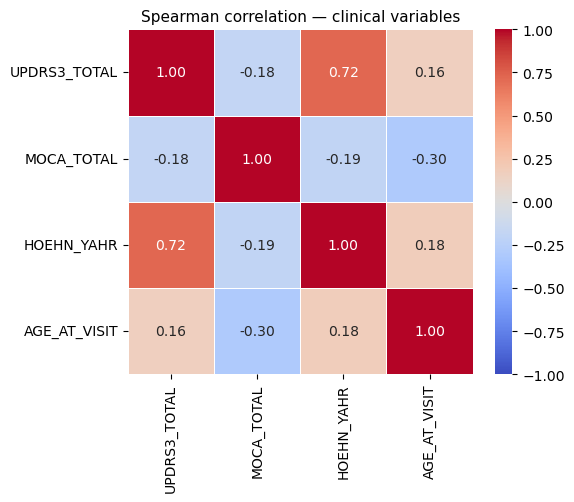

Saved: results/figures/clinical_correlation.png


In [10]:
# INTER-CLINICAL-CORRELATION
corr_cols = ['UPDRS3_TOTAL', 'MOCA_TOTAL', 'HOEHN_YAHR', 'AGE_AT_VISIT']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr(method='spearman')

print("=== Spearman correlation between clinical variables ===")
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax,
    square=True, linewidths=0.5
)
ax.set_title('Spearman correlation — clinical variables', fontsize=11)
plt.tight_layout()
plt.savefig('../../results/figures/clinical_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/clinical_correlation.png")

## 8. Check Patient Overlap Between Latent Files


In [11]:
# Check for patient overlap between training and validation sets using PATNO
train_patnos = set(df_latents['PATNO'].unique())
val_patnos   = set(df_latents_val['PATNO'].unique())
overlap      = train_patnos & val_patnos

print(f"Train: {len(df_latents)} rows, {len(train_patnos)} unique patients")
print(f"Val:   {len(df_latents_val)} rows,   {len(val_patnos)} unique patients")
print(f"\nPatient overlap: {len(overlap)}")
print(f"Overlap Patients: {list(overlap)[:10]}") 

Train: 2373 rows, 1437 unique patients
Val:   591 rows,   521 unique patients

Patient overlap: 317
Overlap Patients: [np.int64(4096), np.int64(4098), np.int64(4108), np.int64(4110), np.int64(4111), np.int64(4114), np.int64(4115), np.int64(4120), np.int64(4121), np.int64(4122)]


In [12]:
# [INVESTIGATE-OVERLAP]

overlap_patnos = train_patnos & val_patnos


# For overlapping patients, how many scans are in train vs val?
overlap_train = df_latents[df_latents['PATNO'].isin(overlap_patnos)]
overlap_val   = df_latents_val[df_latents_val['PATNO'].isin(overlap_patnos)]

print(f"Overlapping patients: {len(overlap_patnos)}")
print(f"\nFor overlapping patients:")
print(f"  Scans in train: {len(overlap_train)}")
print(f"  Scans in val:   {len(overlap_val)}")

print(f"\nScans per overlapping patient in train:")
print(overlap_train.groupby('PATNO').size().describe())

print(f"\nScans per overlapping patient in val:")
print(overlap_val.groupby('PATNO').size().describe())

Overlapping patients: 317

For overlapping patients:
  Scans in train: 619
  Scans in val:   379

Scans per overlapping patient in train:
count    317.000000
mean       1.952681
std        0.807971
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
dtype: float64

Scans per overlapping patient in val:
count    317.000000
mean       1.195584
std        0.435286
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
dtype: float64


In [13]:
# .drop_duplicates('PATNO')

overlap_patnos = train_patnos & val_patnos

# For overlapping patients, how many scans are in train vs val?
overlap_train = df_latents[df_latents['PATNO'].isin(overlap_patnos)]
overlap_val   = df_latents_val[df_latents_val['PATNO'].isin(overlap_patnos)].drop_duplicates('PATNO')

print(f"Overlapping patients: {len(overlap_patnos)}")
print(f"\nFor overlapping patients:")
print(f"  Scans in train: {len(overlap_train)}")
print(f"  Scans in val:   {len(overlap_val)}")

print(f"\nScans per overlapping patient in train:")
print(overlap_train.groupby('PATNO').size().describe())

print(f"\nScans per overlapping patient in val:")
print(overlap_val.groupby('PATNO').size().describe())

Overlapping patients: 317

For overlapping patients:
  Scans in train: 619
  Scans in val:   317

Scans per overlapping patient in train:
count    317.000000
mean       1.952681
std        0.807971
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
dtype: float64

Scans per overlapping patient in val:
count    317.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64


## 8. Patient-Stratified Train/Val Split
All visits from one patient go entirely to train or val — never split across both.  
Stratified by diagnosis label to preserve PD/HC/SWEDD ratio in both splits.


In [14]:
# # [PATIENT-STRATIFIED-SPLIT]
# np.random.seed(RANDOM_STATE)

# patients = df.drop_duplicates(PATIENT_COL)[[PATIENT_COL, LABEL_COL]]

# train_patients = set()
# for label_val in patients[LABEL_COL].unique():
#     group = patients[patients[LABEL_COL] == label_val][PATIENT_COL].tolist()
#     np.random.shuffle(group)
#     n_train = int(TRAIN_RATIO * len(group))
#     train_patients.update(group[:n_train])

# df_train = df[df[PATIENT_COL].isin(train_patients)].copy()
# df_val   = df[~df[PATIENT_COL].isin(train_patients)].copy()

# # Verify zero patient overlap
# overlap = set(df_train[PATIENT_COL]) & set(df_val[PATIENT_COL])
# assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} patients in both splits!"

# print("=== Patient-stratified split ===")
# print(f"\nTraining set:")
# print(f"  Rows:            {len(df_train)}")
# print(f"  Unique patients: {df_train[PATIENT_COL].nunique()}")
# print(f"  Labels:          {df_train[LABEL_COL].value_counts().to_dict()}")
# print(f"\nValidation set:")
# print(f"  Rows:            {len(df_val)}")
# print(f"  Unique patients: {df_val[PATIENT_COL].nunique()}")
# print(f"  Labels:          {df_val[LABEL_COL].value_counts().to_dict()}")
# print(f"\nPatient overlap: {len(overlap)} ✓")

## 9. SBR PCA — Fit Once on Training Set
Fitted objects saved to results/models/ for reuse in all downstream notebooks.  
Never refit on validation data.


In [15]:
# # SBR-PCA-FIT
# # Drop rows with missing SBR values
# df_train = df_train.dropna(subset=SBR_COLS).copy()
# df_val   = df_val.dropna(subset=SBR_COLS).copy()

# # Fit on training set only
# scaler_sbr = StandardScaler()
# sbr_train_scaled = scaler_sbr.fit_transform(df_train[SBR_COLS])

# pca_sbr = PCA(n_components=N_SBR_PCS, random_state=RANDOM_STATE)
# sbr_train_pcs = pca_sbr.fit_transform(sbr_train_scaled)

# for i in range(N_SBR_PCS):
#     df_train[f'SBR_PC{i+1}'] = sbr_train_pcs[:, i]

# # Apply to validation (never refit)
# sbr_val_scaled = scaler_sbr.transform(df_val[SBR_COLS])
# sbr_val_pcs    = pca_sbr.transform(sbr_val_scaled)
# for i in range(N_SBR_PCS):
#     df_val[f'SBR_PC{i+1}'] = sbr_val_pcs[:, i]

# # Save fitted objects
# with open(SCALER_OUT, 'wb') as f: pickle.dump(scaler_sbr, f)
# with open(PCA_OUT,    'wb') as f: pickle.dump(pca_sbr, f)

# print("=== SBR PCA ===")
# print(f"Explained variance: {pca_sbr.explained_variance_ratio_.round(3)}")
# print(f"Total explained:    {pca_sbr.explained_variance_ratio_.sum()*100:.1f}%")
# print(f"\nTrain SBR_PC1: mean={df_train['SBR_PC1'].mean():.3f}, std={df_train['SBR_PC1'].std():.3f}")
# print(f"Val   SBR_PC1: mean={df_val['SBR_PC1'].mean():.3f},   std={df_val['SBR_PC1'].std():.3f}")
# print(f"\nSaved: {SCALER_OUT}")
# print(f"Saved: {PCA_OUT}")

## 10. Save Final Files

In [16]:
# # SAVE-FILES
# df_train.to_csv(TRAIN_OUT, index=False)
# df_val.to_csv(VAL_OUT,     index=False)

# print("=== Files saved ===")
# print(f"\nTrain: {TRAIN_OUT}")
# print(f"  Shape:           {df_train.shape}")
# print(f"  Unique patients: {df_train[PATIENT_COL].nunique()}")

# print(f"\nVal:   {VAL_OUT}")
# print(f"  Shape:           {df_val.shape}")
# print(f"  Unique patients: {df_val[PATIENT_COL].nunique()}")

# print(f"\nClinical coverage in training set:")
# for col in ['UPDRS3_TOTAL', 'HOEHN_YAHR', 'MOCA_TOTAL']:
#     if col in df_train.columns:
#         pct = df_train[col].notna().mean() * 100
#         print(f"  {col:<20} {pct:.1f}%")